# Assignment 10
## Submitted by Chaitanya Jindal

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.graphics.factorplots import interaction_plot
from patsy.builtins import Q

data = pd.read_csv("StudentsPerformance.csv")
data.columns = data.columns.str.strip()

print(f"Dataset shape: {data.shape}")
print(f"Columns: {data.columns.tolist()}")
data.head()

Dataset shape: (1000, 8)
Columns: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


#### Simulate Teaching Method and Prepare Categories

In [2]:
np.random.seed(42)
methods = ['Lecture', 'Online', 'Blended']
data['teaching_method'] = np.random.choice(methods, size=len(data))

data['teaching_method'] = data['teaching_method'].astype('category')
data['gender'] = data['gender'].astype('category')

print(f"Counts by teaching method:")
print(data['teaching_method'].value_counts())

print(f"\nCounts by gender:")
print(data['gender'].value_counts())

Counts by teaching method:
teaching_method
Lecture    355
Online     326
Blended    319
Name: count, dtype: int64

Counts by gender:
gender
female    518
male      482
Name: count, dtype: int64


#### Helper Functions

In [3]:
def partial_eta_squared(anova_table, effect_name):
    ss_effect = anova_table.loc[effect_name, "sum_sq"]
    ss_error = anova_table.loc["Residual", "sum_sq"]
    return ss_effect / (ss_effect + ss_error)

def print_anova_conclusion(title, anova_table, effect_name):
    f_value = anova_table.loc[effect_name, "F"]
    p_value = anova_table.loc[effect_name, "PR(>F)"]
    eta = partial_eta_squared(anova_table, effect_name)
    
    print(f"\n{title}")
    print(f"F-value: {f_value:.4f}")
    print(f"p-value: {p_value:.4f}")
    print(f"Partial eta-squared: {eta:.4f}")
    
    if p_value < 0.05:
        print(f"Conclusion: Reject H₀. The effect is statistically significant.")
    else:
        print(f"Conclusion: Fail to reject H₀. The effect is not statistically significant.")

### Part A: One-Way ANOVA

#### Q1. One-Way ANOVA: Teaching Method → Reading Score
##### Research Question
Does teaching method affect students’ reading scores?
##### Hypotheses
 - H₀: Mean reading score is the same for all teaching methods.
 - H₁: At least one teaching method has a different mean reading score.

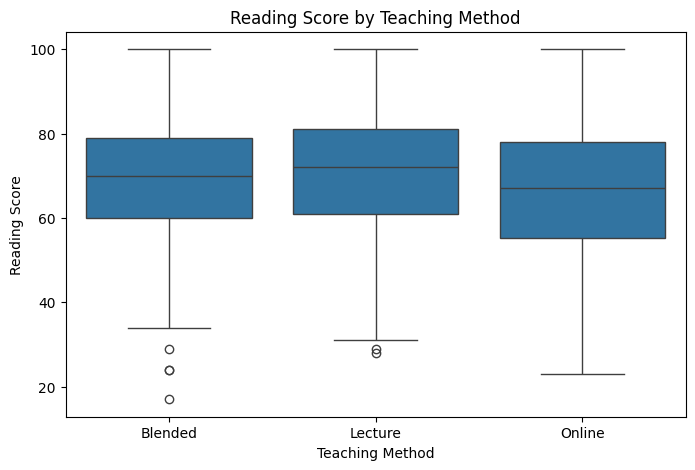

Group means for reading score:
teaching_method
Blended    69.410658
Lecture    71.073239
Online     66.858896
Name: reading score, dtype: float64


In [4]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='teaching_method', y='reading score', data=data)
plt.title('Reading Score by Teaching Method')
plt.xlabel('Teaching Method')
plt.ylabel('Reading Score')
plt.show()

print(f"Group means for reading score:")
print(data.groupby('teaching_method')['reading score'].mean())

In [5]:
print(f"Shapiro-Wilk normality test by group:")
for m in data['teaching_method'].cat.categories:
    vals = data.loc[data['teaching_method'] == m, 'reading score']
    stat, p = stats.shapiro(vals)
    print(f"{m}: W={stat:.4f}, p={p:.4f}")

stat, p = stats.levene(
    data.loc[data['teaching_method'] == 'Lecture', 'reading score'],
    data.loc[data['teaching_method'] == 'Online', 'reading score'],
    data.loc[data['teaching_method'] == 'Blended', 'reading score']
)
print(f"\nLevene test for equal variances: W={stat:.4f}, p={p:.4f}")

Shapiro-Wilk normality test by group:
Blended: W=0.9879, p=0.0090
Lecture: W=0.9882, p=0.0057
Online: W=0.9904, p=0.0319

Levene test for equal variances: W=1.2600, p=0.2841


In [6]:
model_reading = ols('Q("reading score") ~ C(teaching_method)', data=data).fit()
anova_reading = sm.stats.anova_lm(model_reading, typ=2)

print(f"One-Way ANOVA results for Reading Score:")
print(anova_reading)

print_anova_conclusion("Reading Score Analysis", anova_reading, "C(teaching_method)")

One-Way ANOVA results for Reading Score:
                           sum_sq     df         F    PR(>F)
C(teaching_method)    3045.630261    2.0  7.232956  0.000761
Residual            209906.808739  997.0       NaN       NaN

Reading Score Analysis
F-value: 7.2330
p-value: 0.0008
Partial eta-squared: 0.0143
Conclusion: Reject H₀. The effect is statistically significant.


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Blended Lecture   1.6626 0.2984 -0.9649  4.2901  False
Blended  Online  -2.5518 0.0662  -5.234  0.1305  False
Lecture  Online  -4.2143 0.0005 -6.8269 -1.6018   True
------------------------------------------------------


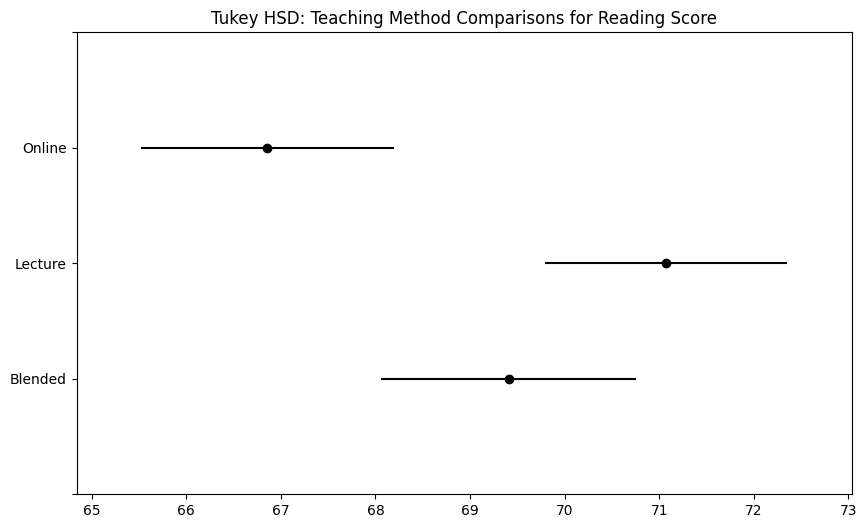

In [8]:
tukey_reading = pairwise_tukeyhsd(endog=data['reading score'], groups=data['teaching_method'], alpha=0.05)
print(tukey_reading)

tukey_reading.plot_simultaneous()
plt.title('Tukey HSD: Teaching Method Comparisons for Reading Score')
plt.show()

#### Q2. One-Way ANOVA: Teaching Method → Writing Score
##### Research Question
Does teaching method affect students’ writing scores?
##### Hypotheses
 - H₀: Mean writing score is the same for all teaching methods.
 - H₁: At least one teaching method has a different mean writing score.

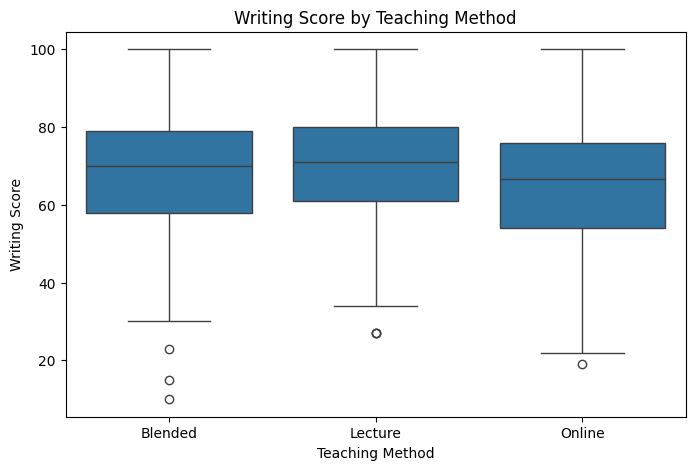

Group means for writing score:
teaching_method
Blended    68.554859
Lecture    69.853521
Online     65.604294
Name: writing score, dtype: float64


In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='teaching_method', y='writing score', data=data)
plt.title('Writing Score by Teaching Method')
plt.xlabel('Teaching Method')
plt.ylabel('Writing Score')
plt.show()

print(f"Group means for writing score:")
print(data.groupby('teaching_method')['writing score'].mean())

In [10]:
print(f"Shapiro-Wilk normality test by group:")
for m in data['teaching_method'].cat.categories:
    vals = data.loc[data['teaching_method'] == m, 'writing score']
    stat, p = stats.shapiro(vals)
    print(f"{m}: W={stat:.4f}, p={p:.4f}")

stat, p = stats.levene(
    data.loc[data['teaching_method'] == 'Lecture', 'writing score'],
    data.loc[data['teaching_method'] == 'Online', 'writing score'],
    data.loc[data['teaching_method'] == 'Blended', 'writing score']
)
print(f"\nLevene test for equal variances: W={stat:.4f}, p={p:.4f}")

Shapiro-Wilk normality test by group:
Blended: W=0.9846, p=0.0017
Lecture: W=0.9889, p=0.0086
Online: W=0.9934, p=0.1613

Levene test for equal variances: W=0.7428, p=0.4761


In [11]:
model_writing = ols('Q("writing score") ~ C(teaching_method)', data=data).fit()
anova_writing = sm.stats.anova_lm(model_writing, typ=2)

print(f"One-Way ANOVA results for Writing Score:")
print(anova_writing)

print_anova_conclusion("Writing Score Analysis", anova_writing, "C(teaching_method)")

One-Way ANOVA results for Writing Score:
                           sum_sq     df         F    PR(>F)
C(teaching_method)    3185.956945    2.0  6.981369  0.000975
Residual            227491.127055  997.0       NaN       NaN

Writing Score Analysis
F-value: 6.9814
p-value: 0.0010
Partial eta-squared: 0.0138
Conclusion: Reject H₀. The effect is statistically significant.


 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
Blended Lecture   1.2987 0.5054 -1.4367   4.034  False
Blended  Online  -2.9506 0.0354 -5.7429 -0.1583   True
Lecture  Online  -4.2492 0.0008  -6.969 -1.5294   True
------------------------------------------------------


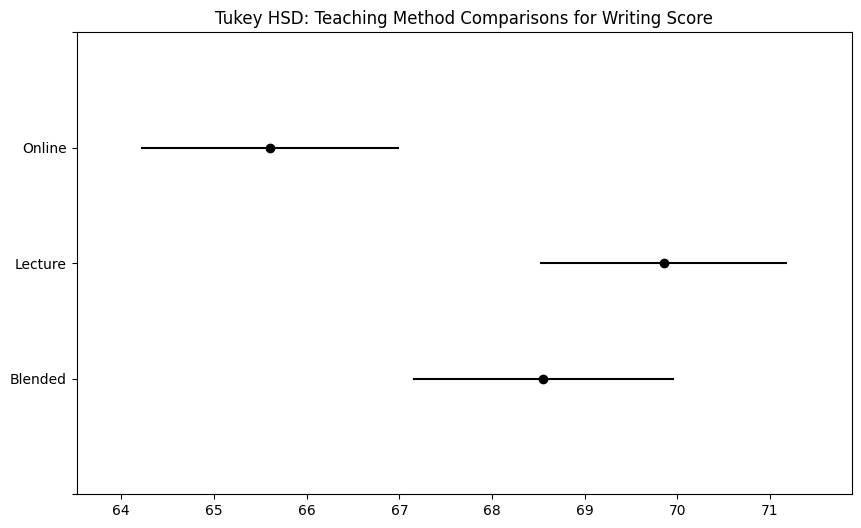

In [12]:
tukey_writing = pairwise_tukeyhsd(endog=data['writing score'], groups=data['teaching_method'], alpha=0.05)
print(tukey_writing)

tukey_writing.plot_simultaneous()
plt.title('Tukey HSD: Teaching Method Comparisons for Writing Score')
plt.show()

### Part B: Two-Way ANOVA

#### Q3. Two-Way ANOVA: Teaching Method × Gender → Reading Score
##### Research Question
Do teaching method and gender influence reading score, and is there an interaction effect?
##### Hypotheses
 - Teaching method main effect
 - Gender main effect
 - Interaction effect

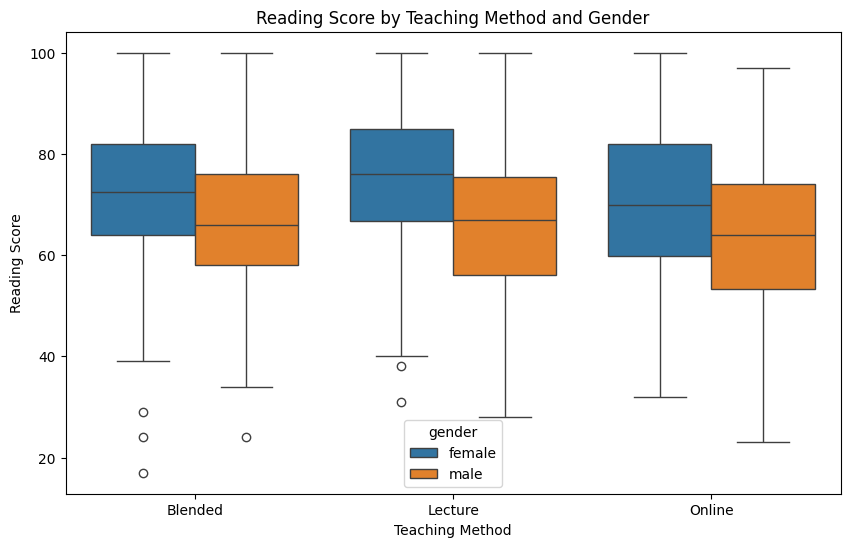

Group means for reading score by teaching method and gender:
gender              female       male
teaching_method                      
Blended          71.656627  66.973856
Lecture          75.312500  66.079755
Online           70.350000  63.493976


In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='teaching_method', y='reading score', hue='gender', data=data)
plt.title('Reading Score by Teaching Method and Gender')
plt.xlabel('Teaching Method')
plt.ylabel('Reading Score')
plt.show()

print(f"Group means for reading score by teaching method and gender:")
print(data.groupby(['teaching_method', 'gender'])['reading score'].mean().unstack())

In [14]:
cells = []
print(f"Shapiro-Wilk p-values by cell:")

for m in data['teaching_method'].cat.categories:
    for g in data['gender'].cat.categories:
        vals = data[(data['teaching_method'] == m) & (data['gender'] == g)]['reading score']
        if len(vals) >= 3:
            stat, p = stats.shapiro(vals)
            print(f"{m} | {g}: n={len(vals)}, p={p:.4f}")
        else:
            print(f"{m} | {g}: n={len(vals)}, p=NA")
        cells.append(vals.values)

levene_stat, levene_p = stats.levene(*cells)
print(f"\nLevene across cells: W={levene_stat:.4f}, p={levene_p:.4f}")

Shapiro-Wilk p-values by cell:
Blended | female: n=166, p=0.0012
Blended | male: n=153, p=0.6519
Lecture | female: n=192, p=0.0252
Lecture | male: n=163, p=0.2286
Online | female: n=160, p=0.0908
Online | male: n=166, p=0.1058

Levene across cells: W=0.7810, p=0.5634


In [15]:
model_reading_2way = ols('Q("reading score") ~ C(teaching_method) + C(gender) + C(teaching_method):C(gender)', data=data).fit()
anova_reading_2way = sm.stats.anova_lm(model_reading_2way, typ=2)

print(f"Two-Way ANOVA results for Reading Score:")
print(anova_reading_2way)

print_anova_conclusion("Reading Score - Teaching Method", anova_reading_2way, "C(teaching_method)")
print_anova_conclusion("Reading Score - Gender", anova_reading_2way, "C(gender)")
print_anova_conclusion("Reading Score - Interaction", anova_reading_2way, "C(teaching_method):C(gender)")

Two-Way ANOVA results for Reading Score:
                                     sum_sq     df          F        PR(>F)
C(teaching_method)              2556.487189    2.0   6.455630  1.638354e-03
C(gender)                      12221.700604    1.0  61.724371  1.021731e-14
C(teaching_method):C(gender)     868.677833    2.0   2.193582  1.120562e-01
Residual                      196816.430302  994.0        NaN           NaN

Reading Score - Teaching Method
F-value: 6.4556
p-value: 0.0016
Partial eta-squared: 0.0128
Conclusion: Reject H₀. The effect is statistically significant.

Reading Score - Gender
F-value: 61.7244
p-value: 0.0000
Partial eta-squared: 0.0585
Conclusion: Reject H₀. The effect is statistically significant.

Reading Score - Interaction
F-value: 2.1936
p-value: 0.1121
Partial eta-squared: 0.0044
Conclusion: Fail to reject H₀. The effect is not statistically significant.


ValueError: This is not a categorial factor. Array of str type required.

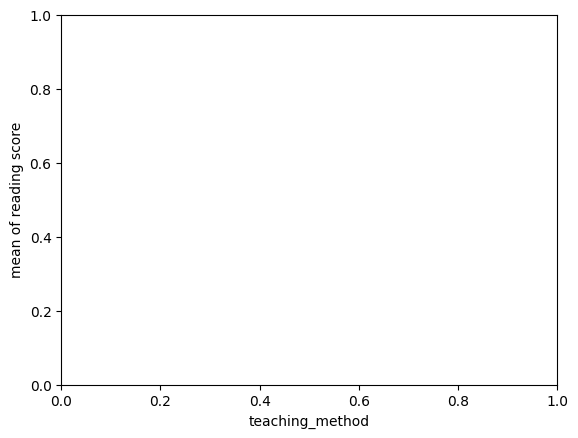

In [16]:
interaction_plot(
    data['teaching_method'],
    data['gender'],
    data['reading score'],
    markers=['o', 's'],
    ms=8
)
plt.title('Interaction Plot: Teaching Method × Gender → Reading Score')
plt.xlabel('Teaching Method')
plt.ylabel('Mean Reading Score')
plt.show()

#### Q4. Two-Way ANOVA: Teaching Method × Gender → Writing Score
##### Research Question
Do teaching method and gender influence writing score, and is there an interaction effect?

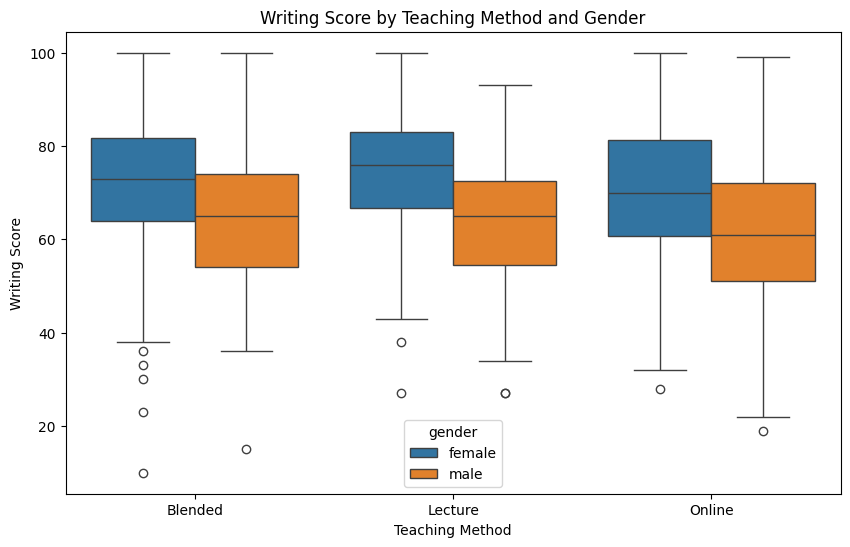

Group means for writing score by teaching method and gender:
gender              female       male
teaching_method                      
Blended          72.000000  64.816993
Lecture          74.947917  63.852761
Online           69.975000  61.391566


In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='teaching_method', y='writing score', hue='gender', data=data)
plt.title('Writing Score by Teaching Method and Gender')
plt.xlabel('Teaching Method')
plt.ylabel('Writing Score')
plt.show()

print(f"Group means for writing score by teaching method and gender:")
print(data.groupby(['teaching_method', 'gender'])['writing score'].mean().unstack())

In [18]:
cells = []
print(f"Shapiro-Wilk p-values by cell:")

for m in data['teaching_method'].cat.categories:
    for g in data['gender'].cat.categories:
        vals = data[(data['teaching_method'] == m) & (data['gender'] == g)]['writing score']
        if len(vals) >= 3:
            stat, p = stats.shapiro(vals)
            print(f"{m} | {g}: n={len(vals)}, p={p:.4f}")
        else:
            print(f"{m} | {g}: n={len(vals)}, p=NA")
        cells.append(vals.values)

levene_stat, levene_p = stats.levene(*cells)
print(f"\nLevene across cells: W={levene_stat:.4f}, p={levene_p:.4f}")

Shapiro-Wilk p-values by cell:
Blended | female: n=166, p=0.0001
Blended | male: n=153, p=0.3509
Lecture | female: n=192, p=0.0096
Lecture | male: n=163, p=0.2089
Online | female: n=160, p=0.1007
Online | male: n=166, p=0.1221

Levene across cells: W=0.9898, p=0.4227


In [19]:
model_writing_2way = ols('Q("writing score") ~ C(teaching_method) + C(gender) + C(teaching_method):C(gender)', data=data).fit()
anova_writing_2way = sm.stats.anova_lm(model_writing_2way, typ=2)

print(f"Two-Way ANOVA results for Writing Score:")
print(anova_writing_2way)

print_anova_conclusion("Writing Score - Teaching Method", anova_writing_2way, "C(teaching_method)")
print_anova_conclusion("Writing Score - Gender", anova_writing_2way, "C(gender)")
print_anova_conclusion("Writing Score - Interaction", anova_writing_2way, "C(teaching_method):C(gender)")

Two-Way ANOVA results for Writing Score:
                                     sum_sq     df          F        PR(>F)
C(teaching_method)              2554.165051    2.0   6.146471  2.223274e-03
C(gender)                      20299.030519    1.0  97.697213  4.865840e-22
C(teaching_method):C(gender)     663.827102    2.0   1.597467  2.029278e-01
Residual                      206528.269434  994.0        NaN           NaN

Writing Score - Teaching Method
F-value: 6.1465
p-value: 0.0022
Partial eta-squared: 0.0122
Conclusion: Reject H₀. The effect is statistically significant.

Writing Score - Gender
F-value: 97.6972
p-value: 0.0000
Partial eta-squared: 0.0895
Conclusion: Reject H₀. The effect is statistically significant.

Writing Score - Interaction
F-value: 1.5975
p-value: 0.2029
Partial eta-squared: 0.0032
Conclusion: Fail to reject H₀. The effect is not statistically significant.


### Part C: Simple Effects Analysis

In [21]:
def simple_effects_anova(df, score_col, factor_col, by_col):
    print(f"\nSimple effects analysis for {score_col}")
    
    for level in df[by_col].cat.categories:
        subset = df[df[by_col] == level]
        print(f"\n--- {by_col} = {level} ---")
        
        model = ols(f'Q("{score_col}") ~ C({factor_col})', data=subset).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        print(anova_table)
        
        f_val = anova_table.loc[f"C({factor_col})", "F"]
        p_val = anova_table.loc[f"C({factor_col})", "PR(>F)"]
        eta = partial_eta_squared(anova_table, f"C({factor_col})")
        
        print(f"F-value: {f_val:.4f}")
        print(f"p-value: {p_val:.4f}")
        print(f"Partial eta-squared: {eta:.4f}")
        
        if p_val < 0.05:
            print(f"Conclusion: Teaching method has a significant effect within {level}.")
            
            tukey = pairwise_tukeyhsd(endog=subset[score_col], groups=subset[factor_col], alpha=0.05)
            print(tukey)
        else:
            print(f"Conclusion: No significant effect of teaching method within {level}.")

In [22]:
interaction_p_reading = anova_reading_2way.loc["C(teaching_method):C(gender)", "PR(>F)"]

if interaction_p_reading < 0.05:
    print(f"Interaction for reading score is significant, so simple effects are needed.")
    simple_effects_anova(data, "reading score", "teaching_method", "gender")
else:
    print(f"Interaction for reading score is not significant, so simple effects are not required.")

Interaction for reading score is not significant, so simple effects are not required.


In [23]:
interaction_p_reading = anova_reading_2way.loc["C(teaching_method):C(gender)", "PR(>F)"]

if interaction_p_reading < 0.05:
    print(f"Interaction for reading score is significant, so simple effects are needed.")
    simple_effects_anova(data, "reading score", "teaching_method", "gender")
else:
    print(f"Interaction for reading score is not significant, so simple effects are not required.")

Interaction for reading score is not significant, so simple effects are not required.


### Part D: Effect Sizes Summary

In [24]:
effect_summary = pd.DataFrame({
    "Reading Score": {
        "Teaching Method": partial_eta_squared(anova_reading_2way, "C(teaching_method)"),
        "Gender": partial_eta_squared(anova_reading_2way, "C(gender)"),
        "Interaction": partial_eta_squared(anova_reading_2way, "C(teaching_method):C(gender)")
    },
    "Writing Score": {
        "Teaching Method": partial_eta_squared(anova_writing_2way, "C(teaching_method)"),
        "Gender": partial_eta_squared(anova_writing_2way, "C(gender)"),
        "Interaction": partial_eta_squared(anova_writing_2way, "C(teaching_method):C(gender)")
    }
})

print(f"Partial Eta-Squared Summary:")
print(effect_summary)

Partial Eta-Squared Summary:
                 Reading Score  Writing Score
Teaching Method       0.012823       0.012216
Gender                0.058466       0.089491
Interaction           0.004394       0.003204


### Final Conclusions

In [25]:
print(f"\n1. Reading Score:")
if anova_reading.loc["C(teaching_method)", "PR(>F)"] < 0.05:
    print(f"Teaching method significantly affects reading score.")
else:
    print(f"Teaching method does not significantly affect reading score.")

if anova_reading_2way.loc["C(gender)", "PR(>F)"] < 0.05:
    print(f"Gender significantly affects reading score.")
else:
    print(f"Gender does not significantly affect reading score.")

if anova_reading_2way.loc["C(teaching_method):C(gender)", "PR(>F)"] < 0.05:
    print(f"There is a significant interaction between teaching method and gender for reading score.")
else:
    print(f"There is no significant interaction for reading score.")

print(f"\n2. Writing Score:")
if anova_writing.loc["C(teaching_method)", "PR(>F)"] < 0.05:
    print(f"Teaching method significantly affects writing score.")
else:
    print(f"Teaching method does not significantly affect writing score.")

if anova_writing_2way.loc["C(gender)", "PR(>F)"] < 0.05:
    print(f"Gender significantly affects writing score.")
else:
    print(f"Gender does not significantly affect writing score.")

if anova_writing_2way.loc["C(teaching_method):C(gender)", "PR(>F)"] < 0.05:
    print(f"There is a significant interaction between teaching method and gender for writing score.")
else:
    print(f"There is no significant interaction for writing score.")


1. Reading Score:
Teaching method significantly affects reading score.
Gender significantly affects reading score.
There is no significant interaction for reading score.

2. Writing Score:
Teaching method significantly affects writing score.
Gender significantly affects writing score.
There is no significant interaction for writing score.
